# Model 2 — temperature model with daily offset and robust likelihood

This notebook fits the advanced Bayesian model:

$$
y_i = \log(PR_i)
$$

$$
y_i \sim StudentT(\nu, \mu_i, \sigma)
$$

$$
\mu_i = \alpha + \beta_T x_{T,i} + \delta_{day[i]}
$$

$$
x_T=\frac{T_m-T_{min}}{T_{max}-T_{min}}, \quad x_T \in [0,1]
$$

$$
\delta_d \sim Normal(0, \sigma_{day})
$$

The model keeps the physically motivated linear temperature effect, but adds:

1. **Student-t likelihood** — robustness to remaining outliers.
2. **Daily latent offset** — day-specific shift in PR caused by unmodelled slow-varying effects.

The daily offset should not be interpreted as direct soiling measurement. It represents unmodelled day-level variation, such as residual irradiance errors, sensor drift, clouds, soiling-like losses, or other daily operating conditions.

In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

RANDOM_SEED = 42

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. Load data

Use the moderate-filtering dataset. This should be the same dataset used for Model 1, so that model comparison is fair.

In [17]:
#DATA_PATH = "onemin-Ground-2016/2016/ground_model_data_moderate.csv"
#DATA_PATH = "onemin-Ground-2016/2016/ground_model_data_sunwindow_5min.csv"
DATA_PATH = "Bayesian-Data-Analytics-PV-Project/onemin-Ground-2016/2016/ground_model_data_irr50_5min.csv"
df = pd.read_csv(DATA_PATH)
print("Using clean data:", DATA_PATH)

STAN_MODEL_PATH = Path("Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset.stan")
STAN_PRIOR_PATH = Path("Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset_prior_predictive.stan")


print("Using data:", DATA_PATH)
print("Raw data shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

required = ["logPR", "PR", "day_id", "T_module_C"]

df = df[df["G_POA_Wm2"] >= 200]
#df = df[df["hour"] >= 7]
#df = df[df["hour"] <= 18]

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=required).copy()

temp_min = df["T_module_C"].min()
temp_max = df["T_module_C"].max()
temp_range = temp_max - temp_min
df["x_T"] = (df["T_module_C"] - temp_min) / temp_range

# filter by irradiance

# Ensure day_id is integer and starts from 1.
df["day_id"] = pd.factorize(df["day_id"])[0] + 1

print("Model data shape:", df.shape)
print("Number of days:", df["day_id"].nunique())
print(f"Temperature range: {temp_min:.2f} ... {temp_max:.2f} degC")

df[["logPR", "PR", "x_T", "day_id", "T_module_C"]].head()

print(DATA_PATH)
print(len(df))
print(df["PR"].quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]))
print(df["G_POA_Wm2"].min(), df["G_POA_Wm2"].max())

Using clean data: Bayesian-Data-Analytics-PV-Project/onemin-Ground-2016/2016/ground_model_data_irr50_5min.csv
Using data: Bayesian-Data-Analytics-PV-Project/onemin-Ground-2016/2016/ground_model_data_irr50_5min.csv
Raw data shape: (6952, 17)
Columns:
['timestamp', 'day', 'day_id', 'month', 'hour', 'logPR', 'PR', 'x_T', 'z_wind', 'z_Tamb', 'T_module_C', 'T_amb_C', 'wind_ms', 'G_POA_Wm2', 'P_DC_kW', 'expected_P_DC_kW', 'power_ratio']
Model data shape: (5465, 17)
Number of days: 57
Temperature range: 14.78 ... 66.68 degC
Bayesian-Data-Analytics-PV-Project/onemin-Ground-2016/2016/ground_model_data_irr50_5min.csv
5465
0.001    0.377255
0.010    0.591120
0.050    0.803531
0.500    0.946163
0.950    1.048298
0.990    1.122559
0.999    1.303198
Name: PR, dtype: float64
200.0 1188.0


## 2. Prepare Stan data

The response is $ y=\log(PR) $.

The temperature predictor is:

$$ x_T = \frac{T_m - T_{min}}{T_{max} - T_{min}} $$

where $T_{min}$ and $T_{max}$ are computed from the filtered modelling dataset. This puts the temperature predictor in the interval $[0,1]$, so it is never negative. One unit of $x_T$ corresponds to moving from the minimum to the maximum observed module temperature. The $+10^\circ C$ effect is used as a physical-scale summary of the temperature relationship.

In [3]:
y = df["logPR"].to_numpy()
x_T = df["x_T"].to_numpy()
day_id = df["day_id"].astype(int).to_numpy()

N = len(df)
J = int(df["day_id"].max())

stan_data = {
    "N": N,
    "J": J,
    "y": y,
    "x_T": x_T,
    "temp_range": temp_range,
    "day_id": day_id,
}

prior_data = {
    "N": N,
    "J": J,
    "x_T": x_T,
    "temp_range": temp_range,
    "day_id": day_id,
}

print(f"N = {N}")
print(f"J = {J}")
print(f"x_T range = {x_T.min():.3f} ... {x_T.max():.3f}")
print(f"Temperature range = {temp_range:.2f} degC")
print(f"PR range = {df['PR'].min():.3f} ... {df['PR'].max():.3f}")

N = 5465
J = 57
x_T range = 0.000 ... 1.000
Temperature range = 51.90 degC
PR range = 0.160 ... 1.847


## 3. EDA motivation for daily offset

Before fitting Model 2, inspect day-to-day variation. If different days have different PR levels, a single global intercept is not enough.

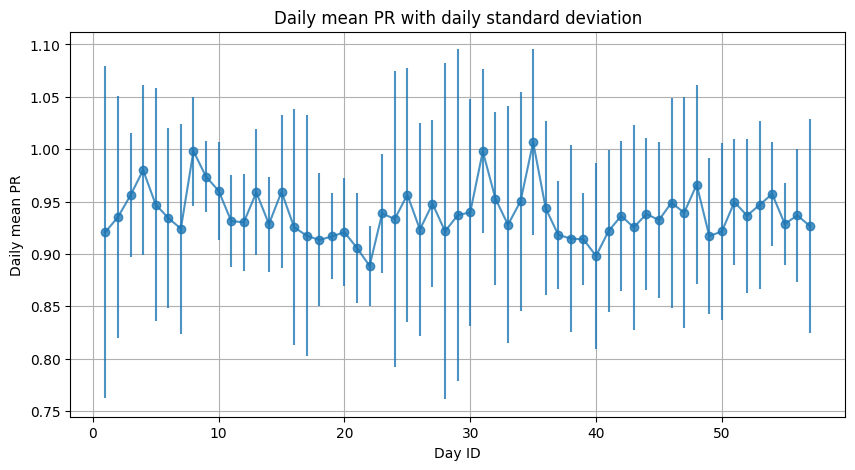

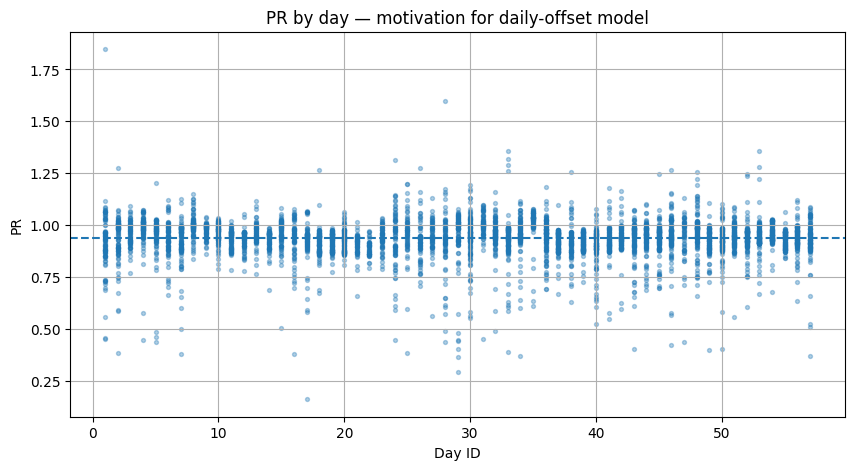

In [4]:
daily = (
    df.groupby("day_id")
    .agg(
        PR_mean=("PR", "mean"),
        PR_std=("PR", "std"),
        n=("PR", "size"),
        T_mean=("T_module_C", "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.errorbar(daily["day_id"], daily["PR_mean"], yerr=daily["PR_std"], fmt="o-", alpha=0.8)
plt.xlabel("Day ID")
plt.ylabel("Daily mean PR")
plt.title("Daily mean PR with daily standard deviation")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(df["day_id"], df["PR"], s=8, alpha=0.35)
plt.axhline(df["PR"].mean(), linestyle="--")
plt.xlabel("Day ID")
plt.ylabel("PR")
plt.title("PR by day — motivation for daily-offset model")
plt.grid(True)
plt.show()

## 4. Prior predictive check

This checks whether the priors generate plausible PR values before seeing the data.

The prior predictive distribution should be wider than the observed data, but it should not be mostly physically absurd. The summaries include $\beta_T$ on the normalized temperature scale and the corresponding $+10^\circ C$ effect for physical interpretation.

In [5]:

prior_model = CmdStanModel(stan_file=str(STAN_PRIOR_PATH))

prior_fit = prior_model.sample(
    data=prior_data,
    fixed_param=True,
    chains=1,
    iter_sampling=1000,
    seed=RANDOM_SEED,
)

alpha_prior = prior_fit.stan_variable("alpha")
beta_T_prior = prior_fit.stan_variable("beta_T")
beta_T_per_10C_prior = prior_fit.stan_variable("beta_T_per_10C")
sigma_prior = prior_fit.stan_variable("sigma")
sigma_day_prior = prior_fit.stan_variable("sigma_day")
nu_prior = prior_fit.stan_variable("nu")
PR_prior = prior_fit.stan_variable("PR_prior")

print("Prior alpha percentiles:", np.percentile(alpha_prior, [5, 50, 95]))
print("Prior beta_T percentiles (0 to 1 temperature scale):", np.percentile(beta_T_prior, [5, 50, 95]))
print("Prior beta_T per +10 degC percentiles:", np.percentile(beta_T_per_10C_prior, [5, 50, 95]))
print("Prior sigma percentiles:", np.percentile(sigma_prior, [5, 50, 95]))
print("Prior sigma_day percentiles:", np.percentile(sigma_day_prior, [5, 50, 95]))
print("Prior nu percentiles:", np.percentile(nu_prior, [5, 50, 95]))
print("Prior predictive PR percentiles:", np.percentile(PR_prior.flatten(), [1, 5, 50, 95, 99]))

00:46:14 - cmdstanpy - INFO - compiling stan file /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset_prior_predictive.stan to exe file /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset_prior_predictive
00:46:25 - cmdstanpy - INFO - compiled model executable: /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset_prior_predictive
00:46:25 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

00:46:31 - cmdstanpy - INFO - CmdStan done processing.



Prior alpha percentiles: [-0.6744985  -0.2198015   0.30329265]
Prior beta_T percentiles (0 to 1 temperature scale): [-0.5939684 -0.190884   0.2130435]
Prior beta_T per +10 degC percentiles: [-0.11444475 -0.03677915  0.04104878]
Prior sigma percentiles: [0.05475947 0.5248035  0.95421455]
Prior sigma_day percentiles: [0.06022113 0.518501   0.95429325]
Prior nu percentiles: [ 9.768809 27.6684   47.49278 ]
Prior predictive PR percentiles: [0.07371999 0.163819   0.731278   3.29358    7.4438901 ]


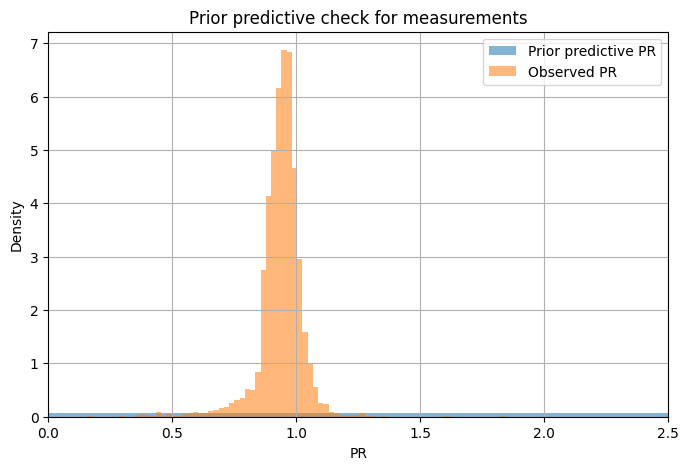

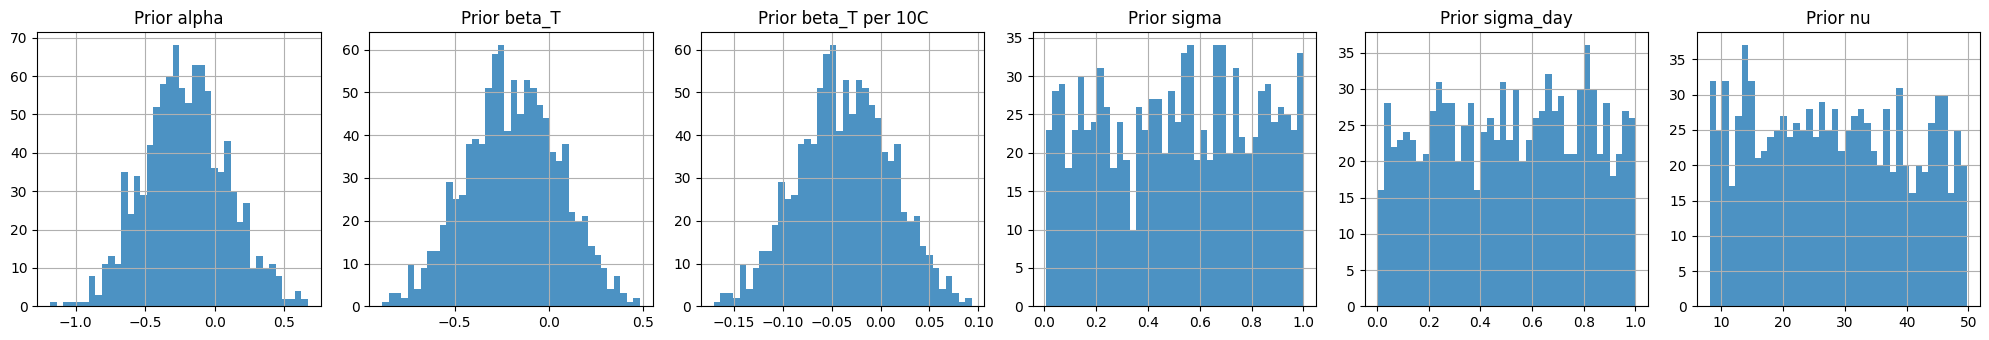

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(PR_prior.flatten(), bins=100, density=True, alpha=0.55, label="Prior predictive PR")
plt.hist(df["PR"], bins=80, density=True, alpha=0.55, label="Observed PR")
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Prior predictive check for measurements")
plt.xlim([0, 2.5])
plt.legend()
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(20, 3.5))
prior_samples = [
    ("alpha", alpha_prior),
    ("beta_T", beta_T_prior),
    ("beta_T per 10C", beta_T_per_10C_prior),
    ("sigma", sigma_prior),
    ("sigma_day", sigma_day_prior),
    ("nu", nu_prior),
]

for ax, (name, samples) in zip(axes, prior_samples):
    ax.hist(samples, bins=40, alpha=0.8)
    ax.set_title(f"Prior {name}")
    ax.grid(True)

plt.tight_layout()
plt.show()

## 5. Fit Model 2

This is the actual advanced model:

$$
\log(PR_i) \sim StudentT(\nu, \alpha + \beta_T x_{T,i} + \delta_{day[i]}, \sigma)
$$

$$
\delta_d = \sigma_{day} z_d, \quad z_d \sim Normal(0,1)
$$

where daily offsets are centered so that the average daily offset is approximately zero.

In [7]:


model = CmdStanModel(stan_file=str(STAN_MODEL_PATH))

fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.95,
    max_treedepth=12,
)

00:46:35 - cmdstanpy - INFO - compiling stan file /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset.stan to exe file /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset
00:46:52 - cmdstanpy - INFO - compiled model executable: /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset
00:46:52 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:49:57 - cmdstanpy - INFO - CmdStan done processing.


## 6. Sampling diagnostics

Check:

- no divergent transitions,
- \(\hat{R}\) close to 1,
- reasonable effective sample sizes.

In [8]:
print(fit.diagnose())

summary = fit.summary()
display(summary.loc[["alpha", "beta_T", "beta_T_per_10C", "sigma", "sigma_day", "nu"]])

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
alpha,0.031176,0.000047,0.002930,0.002874,0.026338,0.031195,0.035985,3992.99,2851.81,1.00022
beta_T,-0.158758,0.000085,0.005167,0.005085,-0.167227,-0.158753,-0.150307,3743.49,2681.23,1.00021
beta_T_per_10C,-0.030589,0.000016,0.000996,0.000980,-0.032221,-0.030588,-0.028961,3743.52,2681.23,1.00021
sigma,0.047710,0.000010,0.000670,0.000674,0.046620,0.047695,0.048811,4711.09,2681.99,1.00031
sigma_day,0.018445,0.000069,0.001926,0.001871,0.015443,0.018327,0.021741,783.44,1313.82,1.00264
nu,5.006070,0.000082,0.006306,0.004262,5.000300,5.004010,5.018670,3809.19,1956.34,1.00031


In [9]:
draws_pd = fit.draws_pd()
div_cols = [c for c in draws_pd.columns if c.endswith("__") and "divergent" in c]
if div_cols:
    n_div = int(draws_pd[div_cols[0]].sum())
else:
    n_div = 0

print("Number of divergences:", n_div)

Number of divergences: 0


## 7. Posterior parameter analysis

The main physical temperature parameter is $\beta_{T,10C}$, the change in $\log(PR)$ associated with a $+10^\circ C$ increase in module temperature. Because $x_T$ is min-max normalized, the model also uses $\beta_T$ as the corresponding effect between the minimum and maximum observed module temperature.

The daily variability is measured by $\sigma_{day}$. A non-zero $\sigma_{day}$ means that day-to-day offsets are relevant.

In [10]:
alpha = fit.stan_variable("alpha")
beta_T = fit.stan_variable("beta_T")
beta_T_per_10C = fit.stan_variable("beta_T_per_10C")
sigma = fit.stan_variable("sigma")
sigma_day = fit.stan_variable("sigma_day")
nu = fit.stan_variable("nu")
delta_day = fit.stan_variable("delta_day")  # shape: draws x J

effect_full_range_pct = 100 * (np.exp(beta_T) - 1)
effect_10C_pct = 100 * (np.exp(beta_T_per_10C) - 1)
effect_1C_pct = 100 * (np.exp(beta_T_per_10C / 10) - 1)

print(f"P(beta_T < 0 | data) = {np.mean(beta_T < 0):.4f}")
print()
print("beta_T posterior percentiles (0 to 1 temperature scale):")
print(np.percentile(beta_T, [5, 50, 95]))
print()
print("beta_T per +10 degC posterior percentiles:")
print(np.percentile(beta_T_per_10C, [5, 50, 95]))
print()
print("Effect across observed temperature range [%] percentiles:")
print(np.percentile(effect_full_range_pct, [5, 50, 95]))
print()
print("Effect per +10 degC [%] percentiles:")
print(np.percentile(effect_10C_pct, [5, 50, 95]))
print()
print("Effect per +1 degC [%] percentiles:")
print(np.percentile(effect_1C_pct, [5, 50, 95]))
print()
print("sigma percentiles:")
print(np.percentile(sigma, [5, 50, 95]))
print()
print("sigma_day percentiles:")
print(np.percentile(sigma_day, [5, 50, 95]))
print()
print("nu percentiles:")
print(np.percentile(nu, [5, 50, 95]))

day_offset_pct = 100 * (np.exp(delta_day) - 1)
print()
print("Daily offset [%] across all days and posterior draws:")
print(np.percentile(day_offset_pct.flatten(), [1, 5, 50, 95, 99]))

P(beta_T < 0 | data) = 1.0000

beta_T posterior percentiles (0 to 1 temperature scale):
[-0.16722745 -0.1587535  -0.1503068 ]

beta_T per +10 degC posterior percentiles:
[-0.03222108 -0.0305883  -0.02896087]

Effect across observed temperature range [%] percentiles:
[-15.39928349 -14.67933515 -13.95560483]

Effect per +10 degC [%] percentiles:
[-3.17075165 -3.01252117 -2.85455233]

Effect per +1 degC [%] percentiles:
[-0.32169231 -0.30541565 -0.28918974]

sigma percentiles:
[0.04661991 0.0476951  0.04881135]

sigma_day percentiles:
[0.01544262 0.0183266  0.02174106]

nu percentiles:
[5.0003    5.00401   5.0186725]

Daily offset [%] across all days and posterior draws:
[-3.79131406 -2.78254087 -0.08629285  3.50220543  4.99351181]


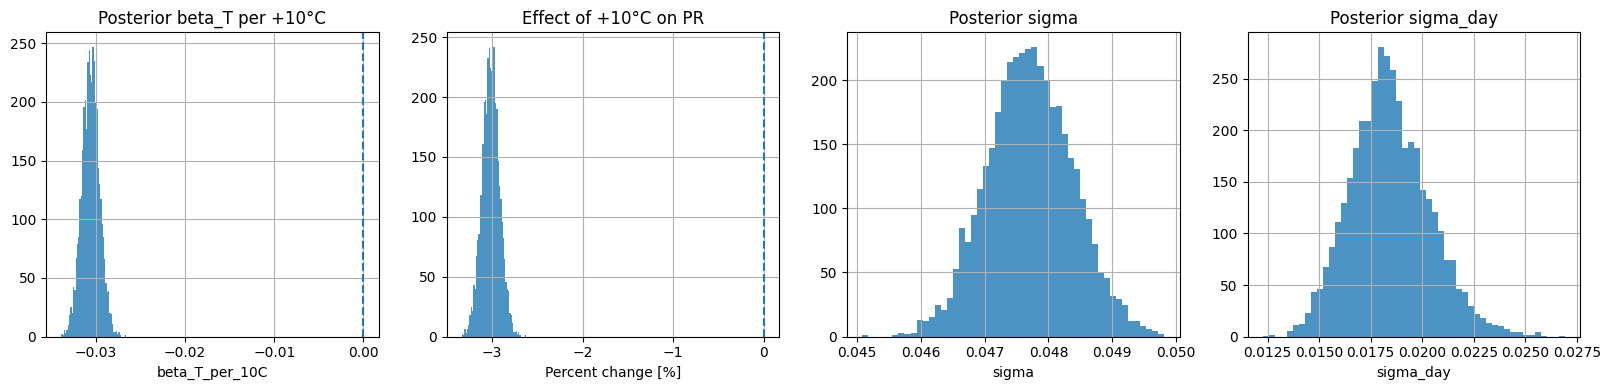

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(beta_T_per_10C, bins=50, alpha=0.8)
axes[0].axvline(0, linestyle="--")
axes[0].set_title("Posterior beta_T per +10°C")
axes[0].set_xlabel("beta_T_per_10C")

axes[1].hist(effect_10C_pct, bins=50, alpha=0.8)
axes[1].axvline(0, linestyle="--")
axes[1].set_title("Effect of +10°C on PR")
axes[1].set_xlabel("Percent change [%]")

axes[2].hist(sigma, bins=50, alpha=0.8)
axes[2].set_title("Posterior sigma")
axes[2].set_xlabel("sigma")

axes[3].hist(sigma_day, bins=50, alpha=0.8)
axes[3].set_title("Posterior sigma_day")
axes[3].set_xlabel("sigma_day")

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()

## 8. Daily offsets

The daily offsets show which days are systematically above or below the global temperature trend.

Positive $\delta_d$: the day has higher PR than expected from temperature alone.

Negative $\delta_d$: the day has lower PR than expected from temperature alone.

/tmp/ipykernel_279/981050565.py:2: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  delta_day_hdi = az.hdi(delta_day, hdi_prob=0.9)


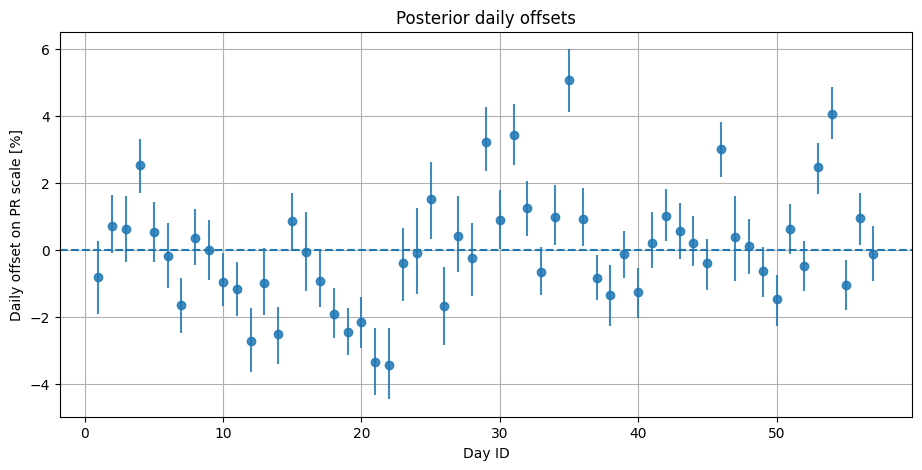

In [12]:
delta_day_mean = delta_day.mean(axis=0)
delta_day_hdi = az.hdi(delta_day, hdi_prob=0.9)

day_numbers = np.arange(1, J + 1)

plt.figure(figsize=(11, 5))
plt.errorbar(
    day_numbers,
    100 * (np.exp(delta_day_mean) - 1),
    yerr=[
        100 * (np.exp(delta_day_mean) - np.exp(delta_day_hdi[:, 0])),
        100 * (np.exp(delta_day_hdi[:, 1]) - np.exp(delta_day_mean)),
    ],
    fmt="o",
    alpha=0.85,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Day ID")
plt.ylabel("Daily offset on PR scale [%]")
plt.title("Posterior daily offsets")
plt.grid(True)
plt.show()

## 9. Posterior predictive check — marginal PR distribution

This is the same type of check as in Model 1, but it should not be the only model check.

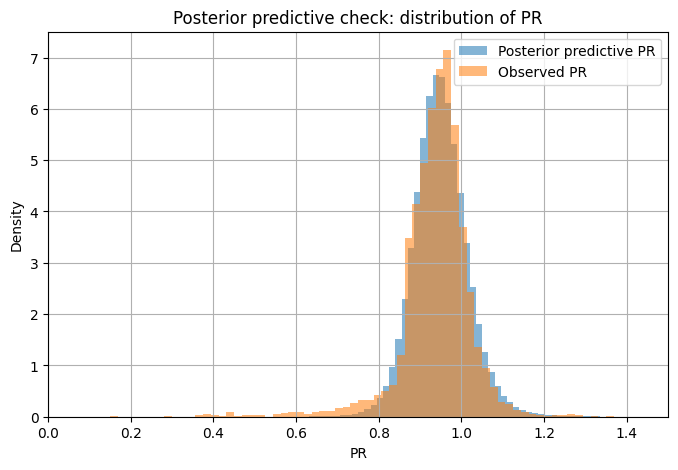

In [19]:
PR_pred = fit.stan_variable("PR_pred")
y_pred = fit.stan_variable("y_pred")
mu = fit.stan_variable("mu")

plt.figure(figsize=(8, 5))
plt.hist(
    PR_pred.flatten(),
    bins=100,
    range=(0, 1.5),
    density=True,
    alpha=0.55,
    label="Posterior predictive PR"
)
plt.hist(
    df["PR"],
    bins=80,
    range=(0, 1.5),
    density=True,
    alpha=0.55,
    label="Observed PR"
)

plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Posterior predictive check: distribution of PR")
plt.xlim([0, 1.5])
plt.legend()
plt.grid(True)
plt.show()

## 10. Posterior predictive checks by day

This is the key check for Model 2.

Model 2 should reduce systematic daily mean residuals compared with Model 1.

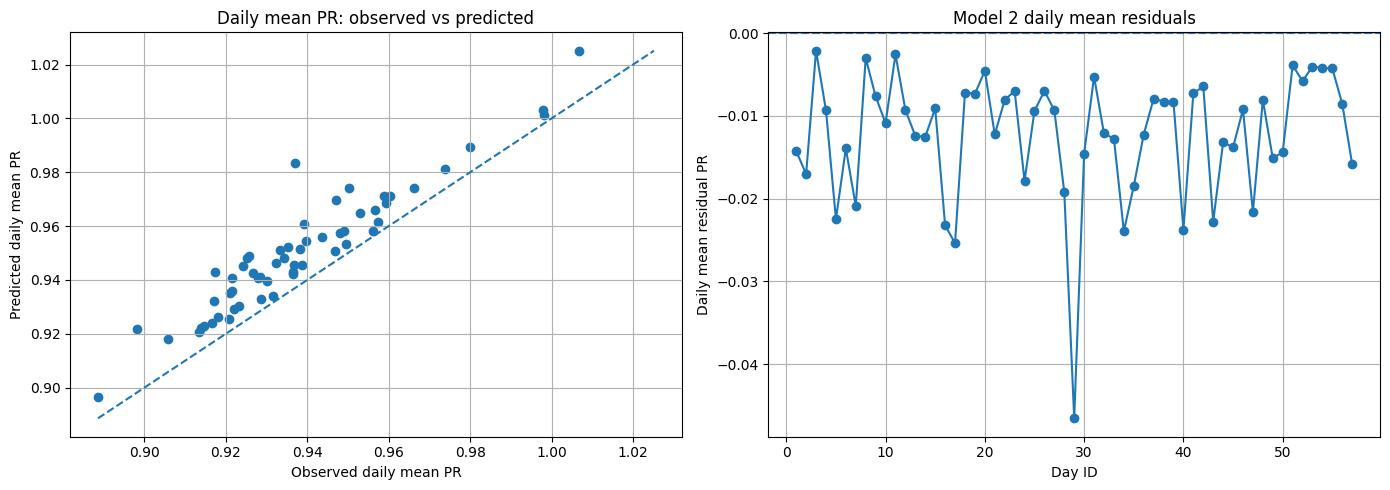

In [14]:
# Use posterior mean of predicted PR for each observation.
PR_pred_mean = PR_pred.mean(axis=0)

df_check = df.copy()
df_check["PR_pred_mean"] = PR_pred_mean
df_check["residual_PR"] = df_check["PR"] - df_check["PR_pred_mean"]

daily_check = (
    df_check.groupby("day_id")
    .agg(
        observed_mean_PR=("PR", "mean"),
        predicted_mean_PR=("PR_pred_mean", "mean"),
        residual_mean_PR=("residual_PR", "mean"),
        n=("PR", "size"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(daily_check["observed_mean_PR"], daily_check["predicted_mean_PR"])
mn = min(daily_check["observed_mean_PR"].min(), daily_check["predicted_mean_PR"].min())
mx = max(daily_check["observed_mean_PR"].max(), daily_check["predicted_mean_PR"].max())
axes[0].plot([mn, mx], [mn, mx], linestyle="--")
axes[0].set_xlabel("Observed daily mean PR")
axes[0].set_ylabel("Predicted daily mean PR")
axes[0].set_title("Daily mean PR: observed vs predicted")
axes[0].grid(True)

axes[1].plot(daily_check["day_id"], daily_check["residual_mean_PR"], "o-")
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Day ID")
axes[1].set_ylabel("Daily mean residual PR")
axes[1].set_title("Model 2 daily mean residuals")
axes[1].grid(True)

plt.tight_layout()
plt.show()

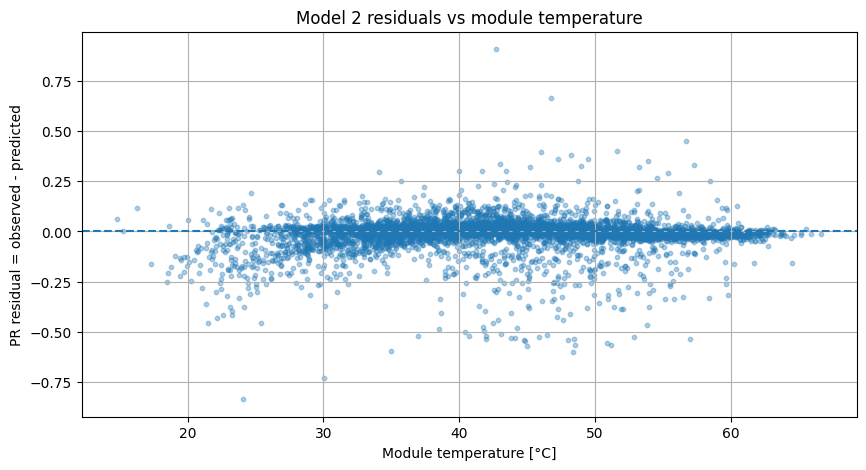

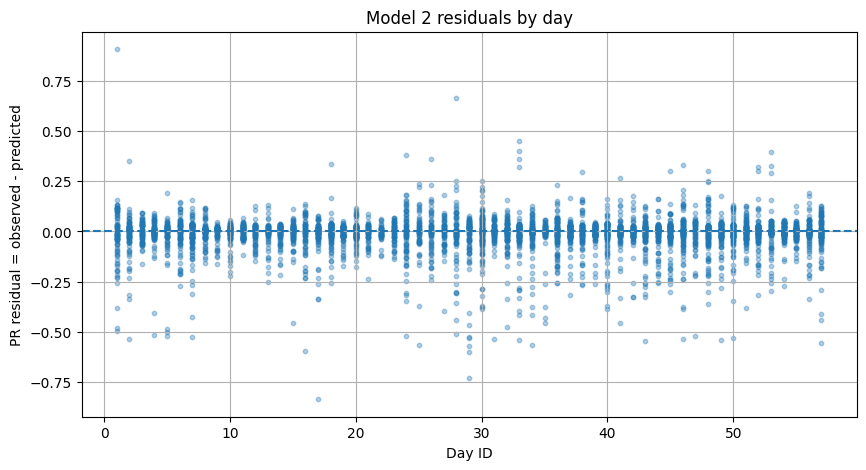

In [15]:
plt.figure(figsize=(10, 5))
plt.scatter(df_check["T_module_C"], df_check["residual_PR"], s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Module temperature [°C]")
plt.ylabel("PR residual = observed - predicted")
plt.title("Model 2 residuals vs module temperature")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(df_check["day_id"], df_check["residual_PR"], s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Day ID")
plt.ylabel("PR residual = observed - predicted")
plt.title("Model 2 residuals by day")
plt.grid(True)
plt.show()

## 11. Save ArviZ object for model comparison

This saves the fitted model for WAIC / PSIS-LOO comparison.

In [16]:
idata2 = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive=["y_pred"],
    observed_data={"y": y},
    log_likelihood=["log_lik"],
)

with open("idata_model2_temperature_daily_offset.pkl", "wb") as f:
    pickle.dump(idata2, f)

print("Saved: idata_model2_temperature_daily_offset.pkl")

Saved: idata_model2_temperature_daily_offset.pkl


## 12. Interpretation template

Use this text after running the notebook and replacing the numerical values with your output:

The advanced model keeps the physically motivated linear temperature effect, but adds a robust Student-t likelihood and a latent daily offset. The posterior for $\beta_T$ remains negative, which confirms the temperature-related loss in normalized PV performance. The posterior of $\sigma_{day}$ indicates whether day-to-day variability is relevant. Compared with the Gaussian baseline, this model should better capture systematic daily deviations and remaining outliers.